# Correlación NE – NDVI/EVI – Pozo Sabanas de Cali
Notebook generado con la tabla reducida corregida. Incluye correlación global, por estación, desfases, integración CHIRPS y modelo predictivo.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [ ]:
data = [('2015-01-05', 95.42, 0.350329409, 0.512337512, 'Verano'), ('2015-12-24', 97.1, 0.396305341, 0.651932588, 'Invierno'), ('2016-01-18', 97.4, 0.401552863, 0.661623815, 'Verano'), ('2016-11-12', 98.6, 0.369840908, 0.614463828, 'Invierno'), ('2017-02-08', 98.93, 0.411932286, 0.659327302, 'Verano'), ('2017-12-18', 101.03, 0.406800386, 0.671315043, 'Invierno'), ('2018-02-01', 100.79, 0.338128952, 0.56730384, 'Verano'), ('2018-12-08', 102.19, 0.454023664, 0.704190776, 'Invierno'), ('2019-01-02', 103.08, 0.313443527, 0.510061608, 'Verano'), ('2019-11-23', 105.76, 0.598211909, 0.726102418, 'Invierno'), ('2020-01-02', 105.38, 0.322284689, 0.568354302, 'Verano'), ('2020-12-27', 107.11, 0.501008601, 0.706152982, 'Invierno'), ('2021-01-06', 107.32, 0.39411828, 0.675089942, 'Verano'), ('2021-12-02', 109.36, 0.57356438, 0.763627455, 'Invierno'), ('2022-01-01', 108.6, 0.377199932, 0.684928722, 'Verano'), ('2022-12-02', 110.78, 0.485114441, 0.759409237, 'Invierno'), ('2023-02-05', 111.03, 0.40198081, 0.624675214, 'Verano'), ('2023-11-27', 112.2, 0.550281367, 0.823721622, 'Invierno'), ('2024-01-01', 112.5, 0.366731065, 0.631852846, 'Verano'), ('2024-12-16', 112.44, 0.429709914, 0.671529282, 'Invierno'), ('2025-07-24', 114.39, 0.522367733, 0.474779905, 'Verano'), ('2025-12-21', 115.37, 0.502065256, 0.753538101, 'Invierno')]
df = pd.DataFrame(data, columns=['Fecha','NE','EVI','NDVI','Estacion'])
df['Fecha'] = pd.to_datetime(df['Fecha'])
df.head()


,Fecha,NE,EVI,NDVI,Estacion
0,2015-01-05,95.42,0.350329,0.512338,Verano
1,2015-12-24,97.10,0.396305,0.651933,Invierno
2,2016-01-18,97.40,0.401553,0.661624,Verano
3,2016-11-12,98.60,0.369841,0.614464,Invierno
4,2017-02-08,98.93,0.411932,0.659327,Verano


In [ ]:
def pair_corrs(g, name):
    rows = []
    for method in ['pearson','spearman']:
        c = g[['NE','EVI','NDVI']].corr(method=method)
        for pair, a, b in [('NE-EVI','NE','EVI'), ('NE-NDVI','NE','NDVI'), ('EVI-NDVI','EVI','NDVI')]:
            rows.append([name, method, pair, c.loc[a,b], len(g)])
    return rows

corrs = pd.DataFrame(sum([pair_corrs(g,n) for n,g in [('Global',df),('Verano',df[df.Estacion=='Verano']),('Invierno',df[df.Estacion=='Invierno'])]], []), columns=['Serie','Metodo','Par','r','n'])
corrs


,Serie,Metodo,Par,r,n
0,Global,pearson,NE-EVI,0.483368,22
1,Global,pearson,NE-NDVI,0.322025,22
2,Global,pearson,EVI-NDVI,0.632101,22
3,Global,spearman,NE-EVI,0.462451,22
4,Global,spearman,NE-NDVI,0.352908,22
5,Global,spearman,EVI-NDVI,0.712027,22
6,Verano,pearson,NE-EVI,0.437133,11
7,Verano,pearson,NE-NDVI,0.000221,11
8,Verano,pearson,EVI-NDVI,-0.042785,11
9,Verano,spearman,NE-EVI,0.290909,11


In [ ]:
lag_rows = []
for name, g in [('Global',df),('Verano',df[df.Estacion=='Verano']),('Invierno',df[df.Estacion=='Invierno'])]:
    g = g.sort_values('Fecha').reset_index(drop=True)
    for lag in range(-5, 6):
        for var in ['NDVI','EVI']:
            shifted = g[var].shift(lag)
            r = g['NE'].corr(shifted)
            n = pd.concat([g['NE'], shifted], axis=1).dropna().shape[0]
            lag_rows.append([name,var,lag,r,n])
lags = pd.DataFrame(lag_rows, columns=['Serie','Indice','Lag_observaciones','r','n'])
best_lags = lags.loc[lags.groupby(['Serie','Indice'])['r'].apply(lambda s: s.abs().idxmax()).values].sort_values(['Serie','Indice'])
best_lags


,Serie,Indice,Lag_observaciones,r,n
19,Global,EVI,4,0.483937,18
18,Global,NDVI,4,0.572868,18
63,Invierno,EVI,4,0.868712,7
58,Invierno,NDVI,2,0.945308,9
25,Verano,EVI,-4,0.799480,7
22,Verano,NDVI,-5,-0.491394,6


## Integración CHIRPS en GEE
Ejecuta este bloque en Google Earth Engine y exporta el CSV mensual de precipitación. Después súbelo a Colab y usa la celda siguiente para integrarlo.

In [ ]:

// ============================
// CHIRPS: precipitación acumulada alrededor del pozo
// ============================
var pozo = ee.Geometry.Point([-75.288714, 9.356633]);
var area_lluvia = pozo.buffer(5000);  // CHIRPS ~5 km, usar buffer amplio

var chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY')
  .filterBounds(area_lluvia)
  .filterDate('2015-01-01', '2025-12-31');

var monthly = ee.ImageCollection(
  ee.List.sequence(2015, 2025).map(function(y) {
    return ee.List.sequence(1, 12).map(function(m) {
      var start = ee.Date.fromYMD(y, m, 1);
      var end = start.advance(1, 'month');
      var img = chirps.filterDate(start, end).sum().rename('P_mm');
      return img.set({
        'date': start.format('YYYY-MM-dd'),
        'year': y,
        'month': m,
        'system:time_start': start.millis()
      });
    });
  }).flatten()
);

var lluvia_series = monthly.map(function(image) {
  var stats = image.reduceRegion({
    reducer: ee.Reducer.mean(),
    geometry: area_lluvia,
    scale: 5000,
    maxPixels: 1e9
  });
  return ee.Feature(null, {
    'date': image.get('date'),
    'year': image.get('year'),
    'month': image.get('month'),
    'P_mm': stats.get('P_mm')
  });
});

Export.table.toDrive({
  collection: lluvia_series,
  description: 'CHIRPS_Mensual_Pozo_SabanasCali',
  fileFormat: 'CSV'
});


In [ ]:
# Integración en Colab después de exportar CHIRPS_Mensual_Pozo_SabanasCali.csv
# lluvia = pd.read_csv('/content/CHIRPS_Mensual_Pozo_SabanasCali.csv')
# lluvia['date'] = pd.to_datetime(lluvia['date'])
# lluvia = lluvia.sort_values('date')
# lluvia['P_3m'] = lluvia['P_mm'].rolling(3, min_periods=1).sum()
# lluvia['P_6m'] = lluvia['P_mm'].rolling(6, min_periods=1).sum()
# df_lluvia = pd.merge_asof(df.sort_values('Fecha'), lluvia.sort_values('date'), left_on='Fecha', right_on='date', direction='backward', tolerance=pd.Timedelta('45D'))
# df_lluvia[['Fecha','NE','NDVI','EVI','P_mm','P_3m','P_6m']].corr()


In [ ]:
d = df.copy()
d['t_year'] = d['Fecha'].dt.year + (d['Fecha'].dt.dayofyear - 1) / 365.25
d['month'] = d['Fecha'].dt.month
d['sin_mes'] = np.sin(2*np.pi*d['month']/12)
d['cos_mes'] = np.cos(2*np.pi*d['month']/12)

model_rows = []
for name, feats in [('Indices solamente',['EVI','NDVI']), ('Tendencia temporal + indices',['t_year','EVI','NDVI']), ('Tendencia + indices + estacionalidad',['t_year','EVI','NDVI','sin_mes','cos_mes'])]:
    X = d[feats]
    y = d['NE']
    y_pred = cross_val_predict(LinearRegression(), X, y, cv=LeaveOneOut())
    model = LinearRegression().fit(X, y)
    model_rows.append([name, ', '.join(feats), r2_score(y, y_pred), np.sqrt(mean_squared_error(y, y_pred)), mean_absolute_error(y, y_pred), model.score(X,y), model.intercept_, dict(zip(feats, model.coef_))])
models = pd.DataFrame(model_rows, columns=['Modelo','Variables','R2_LOOCV','RMSE_LOOCV_m','MAE_LOOCV_m','R2_ajuste','Intercepto','Coeficientes'])
models


,Modelo,Variables,R2_LOOCV,RMSE_LOOCV_m,MAE_LOOCV_m,R2_ajuste,Intercepto,Coeficientes
0,Indices solamente,"EVI, NDVI",-0.371038,7.031989,5.879442,0.234097,89.472898,"{'EVI': 34.95579925481996, 'NDVI': 1.904080600..."
1,Tendencia temporal + indices,"t_year, EVI, NDVI",0.982254,0.800024,0.644499,0.990691,-3577.327121,"{'t_year': 1.8220651517821962, 'EVI': 1.485715..."
2,Tendencia + indices + estacionalidad,"t_year, EVI, NDVI, sin_mes, cos_mes",0.985027,0.734866,0.603810,0.992103,-3615.350338,"{'t_year': 1.8407687790138363, 'EVI': 6.470759..."


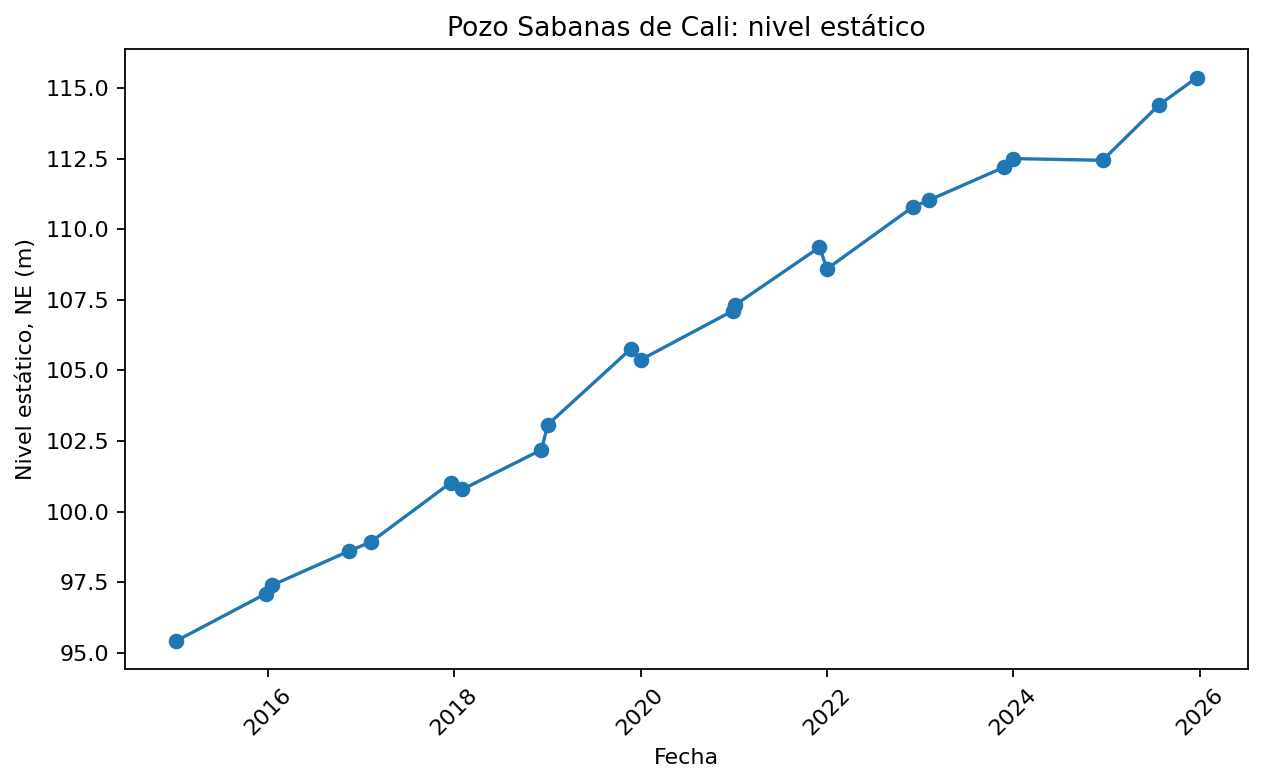

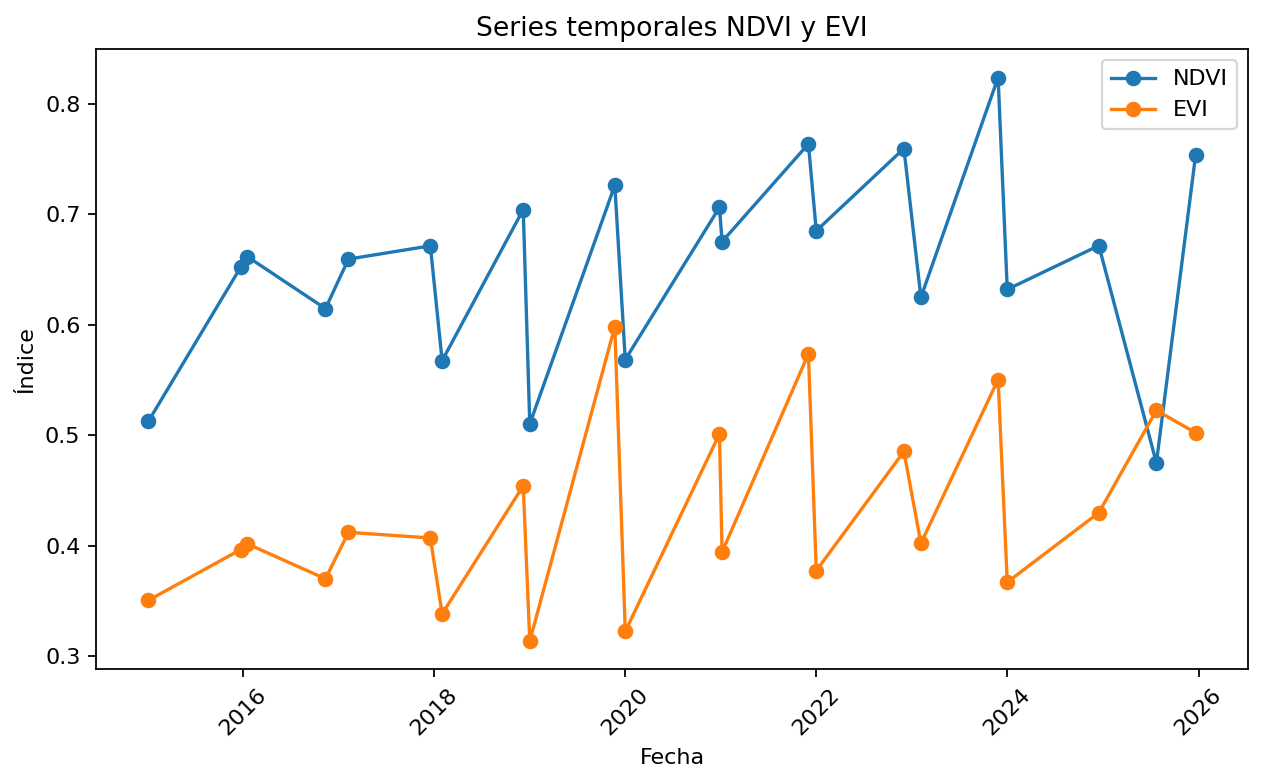

In [ ]:
plt.figure(figsize=(8,5), dpi=160)
plt.plot(df['Fecha'], df['NE'], marker='o')
plt.xlabel('Fecha')
plt.ylabel('Nivel estático, NE (m)')
plt.title('Pozo Sabanas de Cali: nivel estático')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5), dpi=160)
plt.plot(df['Fecha'], df['NDVI'], marker='o', label='NDVI')
plt.plot(df['Fecha'], df['EVI'], marker='o', label='EVI')
plt.xlabel('Fecha')
plt.ylabel('Índice')
plt.title('Series temporales NDVI y EVI')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


            NE      NDVI       EVI      P_1m      P_3m      P_6m
NE    1.000000  0.321950  0.483236  0.230495  0.269005  0.238575
NDVI  0.321950  1.000000  0.632112  0.057987  0.331710  0.463231
EVI   0.483236  0.632112  1.000000  0.416140  0.701187  0.542198
P_1m  0.230495  0.057987  0.416140  1.000000  0.789461  0.573669
P_3m  0.269005  0.331710  0.701187  0.789461  1.000000  0.838289
P_6m  0.238575  0.463231  0.542198  0.573669  0.838289  1.000000


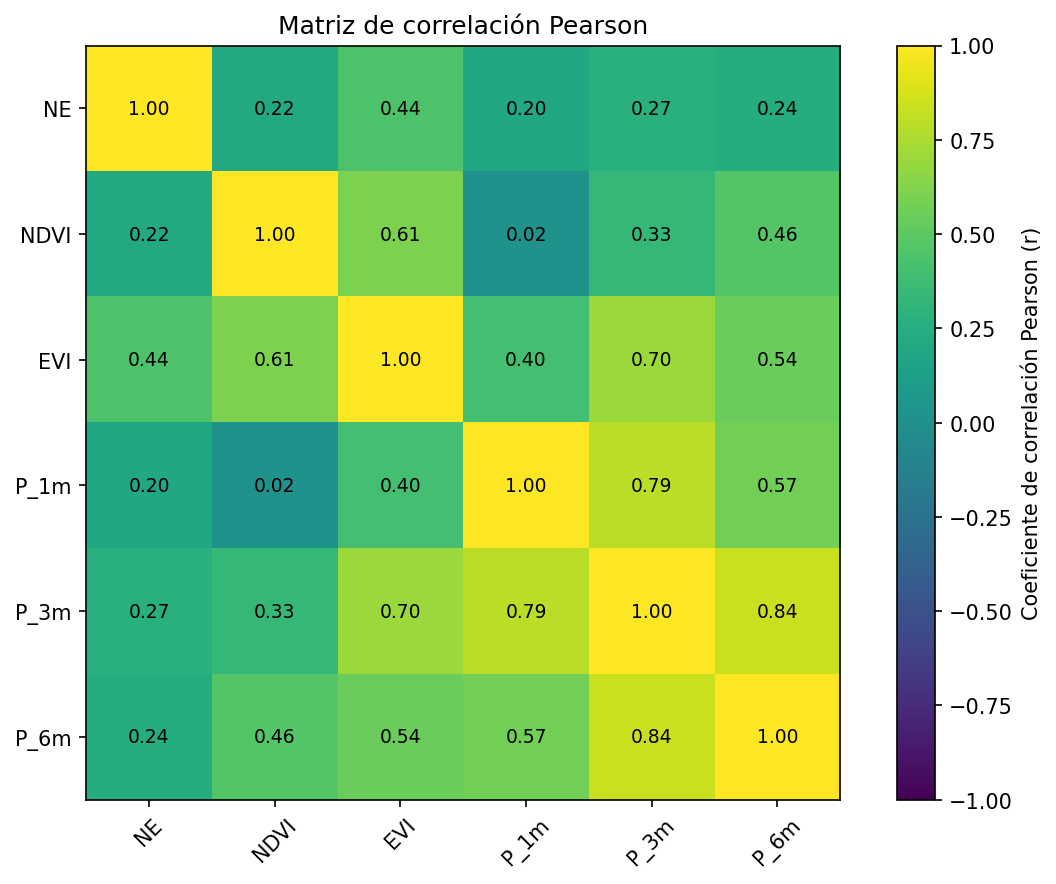

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================
# 1. DATOS DEL POZO
# ============================
data = [
("2015-01-05",95.42,0.3503,0.5123),
("2015-12-24",97.10,0.3963,0.6519),
("2016-01-18",97.40,0.4015,0.6616),
("2016-11-12",98.60,0.3698,0.6144),
("2017-02-08",98.93,0.4119,0.6593),
("2017-12-18",101.03,0.4068,0.6713),
("2018-02-01",100.79,0.3381,0.5673),
("2018-12-08",102.19,0.4540,0.7041),
("2019-01-02",103.08,0.3134,0.5100),
("2019-11-23",105.76,0.5982,0.7261),
("2020-01-02",105.38,0.3222,0.5683),
("2020-12-27",107.11,0.5010,0.7061),
("2021-01-06",107.32,0.3941,0.6750),
("2021-12-02",109.36,0.5735,0.7636),
("2022-01-01",108.60,0.3771,0.6849),
("2022-12-02",110.78,0.4851,0.7594),
("2023-02-05",111.03,0.4019,0.6246),
("2023-11-27",112.20,0.5502,0.8237),
("2024-01-01",112.50,0.3667,0.6318),
("2024-12-16",112.44,0.4297,0.6715),
("2025-07-24",114.39,0.5223,0.4747),
("2025-12-21",115.37,0.5020,0.7535)
]

df = pd.DataFrame(data, columns=["Fecha","NE","EVI","NDVI"])
df["Fecha"] = pd.to_datetime(df["Fecha"])

# ============================
# 2. CHIRPS (archivo que subiste)
# ============================
chirps = pd.read_csv('/content/CHIRPS_Mensual_Pozo_SabanasCali.csv')

chirps["date"] = pd.to_datetime(chirps["date"])
chirps = chirps.sort_values("date")

# ============================
# 3. ACUMULADOS (CLAVE)
# ============================
chirps["P_1m"] = chirps["P_mm"]
chirps["P_3m"] = chirps["P_mm"].rolling(3).sum()
chirps["P_6m"] = chirps["P_mm"].rolling(6).sum()

# ============================
# 4. EMPAREJAMIENTO TEMPORAL
# ============================
df_merge = pd.merge_asof(
    df.sort_values("Fecha"),
    chirps.sort_values("date"),
    left_on="Fecha",
    right_on="date",
    direction="backward",
    tolerance=pd.Timedelta("45D")
)

# ============================
# 5. MATRIZ DE CORRELACIÓN
# ============================
corr = df_merge[["NE","NDVI","EVI","P_1m","P_3m","P_6m"]].corr()

print(corr)


# ============================
# VARIABLES A ANALIZAR
# ============================
vars_corr = ["NE", "NDVI", "EVI", "P_1m", "P_3m", "P_6m"]

df_corr = df_merge[vars_corr].dropna()

# ============================
# MATRIZ PEARSON
# ============================
corr_pearson = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6), dpi=150)
plt.imshow(corr_pearson, vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlación Pearson (r)")

plt.xticks(range(len(vars_corr)), vars_corr, rotation=45)
plt.yticks(range(len(vars_corr)), vars_corr)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        plt.text(
            j, i,
            f"{corr_pearson.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Matriz de correlación Pearson")
plt.tight_layout()
plt.show()
print(corr_pearson)
print(corr_pearson)

            NE      NDVI       EVI      P_1m      P_3m      P_6m
NE    1.000000  0.321950  0.483236  0.230495  0.269005  0.238575
NDVI  0.321950  1.000000  0.632112  0.057987  0.331710  0.463231
EVI   0.483236  0.632112  1.000000  0.416140  0.701187  0.542198
P_1m  0.230495  0.057987  0.416140  1.000000  0.789461  0.573669
P_3m  0.269005  0.331710  0.701187  0.789461  1.000000  0.838289
P_6m  0.238575  0.463231  0.542198  0.573669  0.838289  1.000000


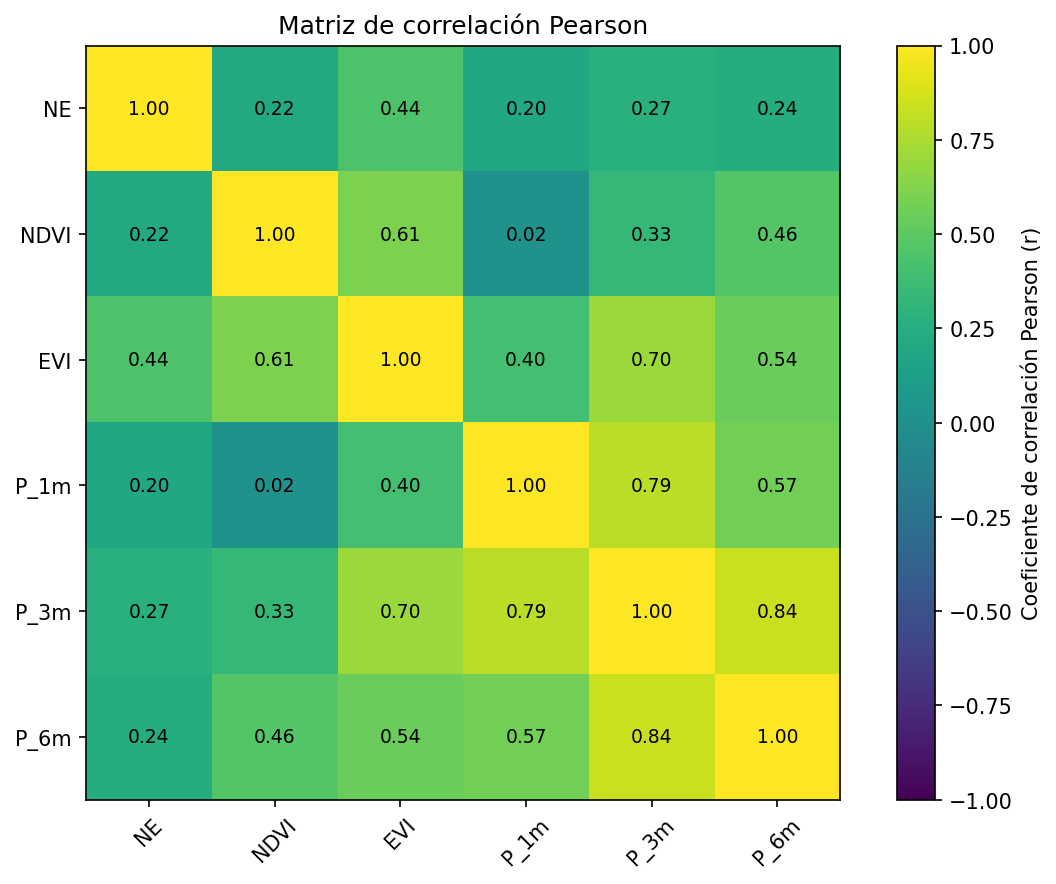

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================
# 1. DATOS DEL POZO
# ============================
data = [
("2015-01-05",95.42,0.3503,0.5123),
("2015-12-24",97.10,0.3963,0.6519),
("2016-01-18",97.40,0.4015,0.6616),
("2016-11-12",98.60,0.3698,0.6144),
("2017-02-08",98.93,0.4119,0.6593),
("2017-12-18",101.03,0.4068,0.6713),
("2018-02-01",100.79,0.3381,0.5673),
("2018-12-08",102.19,0.4540,0.7041),
("2019-01-02",103.08,0.3134,0.5100),
("2019-11-23",105.76,0.5982,0.7261),
("2020-01-02",105.38,0.3222,0.5683),
("2020-12-27",107.11,0.5010,0.7061),
("2021-01-06",107.32,0.3941,0.6750),
("2021-12-02",109.36,0.5735,0.7636),
("2022-01-01",108.60,0.3771,0.6849),
("2022-12-02",110.78,0.4851,0.7594),
("2023-02-05",111.03,0.4019,0.6246),
("2023-11-27",112.20,0.5502,0.8237),
("2024-01-01",112.50,0.3667,0.6318),
("2024-12-16",112.44,0.4297,0.6715),
("2025-07-24",114.39,0.5223,0.4747),
("2025-12-21",115.37,0.5020,0.7535)
]

df = pd.DataFrame(data, columns=["Fecha","NE","EVI","NDVI"])
df["Fecha"] = pd.to_datetime(df["Fecha"])

# ============================
# 2. CHIRPS (archivo que subiste)
# ============================
chirps = pd.read_csv('/content/CHIRPS_Mensual_Pozo_SabanasCali.csv')

chirps["date"] = pd.to_datetime(chirps["date"])
chirps = chirps.sort_values("date")

# ============================
# 3. ACUMULADOS (CLAVE)
# ============================
chirps["P_1m"] = chirps["P_mm"]
chirps["P_3m"] = chirps["P_mm"].rolling(3).sum()
chirps["P_6m"] = chirps["P_mm"].rolling(6).sum()

# ============================
# 4. EMPAREJAMIENTO TEMPORAL
# ============================
df_merge = pd.merge_asof(
    df.sort_values("Fecha"),
    chirps.sort_values("date"),
    left_on="Fecha",
    right_on="date",
    direction="backward",
    tolerance=pd.Timedelta("45D")
)

# ============================
# 5. MATRIZ DE CORRELACIÓN
# ============================
corr = df_merge[["NE","NDVI","EVI","P_1m","P_3m","P_6m"]].corr()

print(corr)


# ============================
# VARIABLES A ANALIZAR
# ============================
vars_corr = ["NE", "NDVI", "EVI", "P_1m", "P_3m", "P_6m"]

df_corr = df_merge[vars_corr].dropna()

# ============================
# MATRIZ PEARSON
# ============================
corr_pearson = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6), dpi=150)
plt.imshow(corr_pearson, vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlación Pearson (r)")

plt.xticks(range(len(vars_corr)), vars_corr, rotation=45)
plt.yticks(range(len(vars_corr)), vars_corr)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        plt.text(
            j, i,
            f"{corr_pearson.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Matriz de correlación Pearson")
plt.tight_layout()
plt.show()
print(corr_pearson)
print(corr_pearson)

            NE      NDVI       EVI      P_1m      P_3m      P_6m
NE    1.000000  0.321950  0.483236  0.230495  0.269005  0.238575
NDVI  0.321950  1.000000  0.632112  0.057987  0.331710  0.463231
EVI   0.483236  0.632112  1.000000  0.416140  0.701187  0.542198
P_1m  0.230495  0.057987  0.416140  1.000000  0.789461  0.573669
P_3m  0.269005  0.331710  0.701187  0.789461  1.000000  0.838289
P_6m  0.238575  0.463231  0.542198  0.573669  0.838289  1.000000


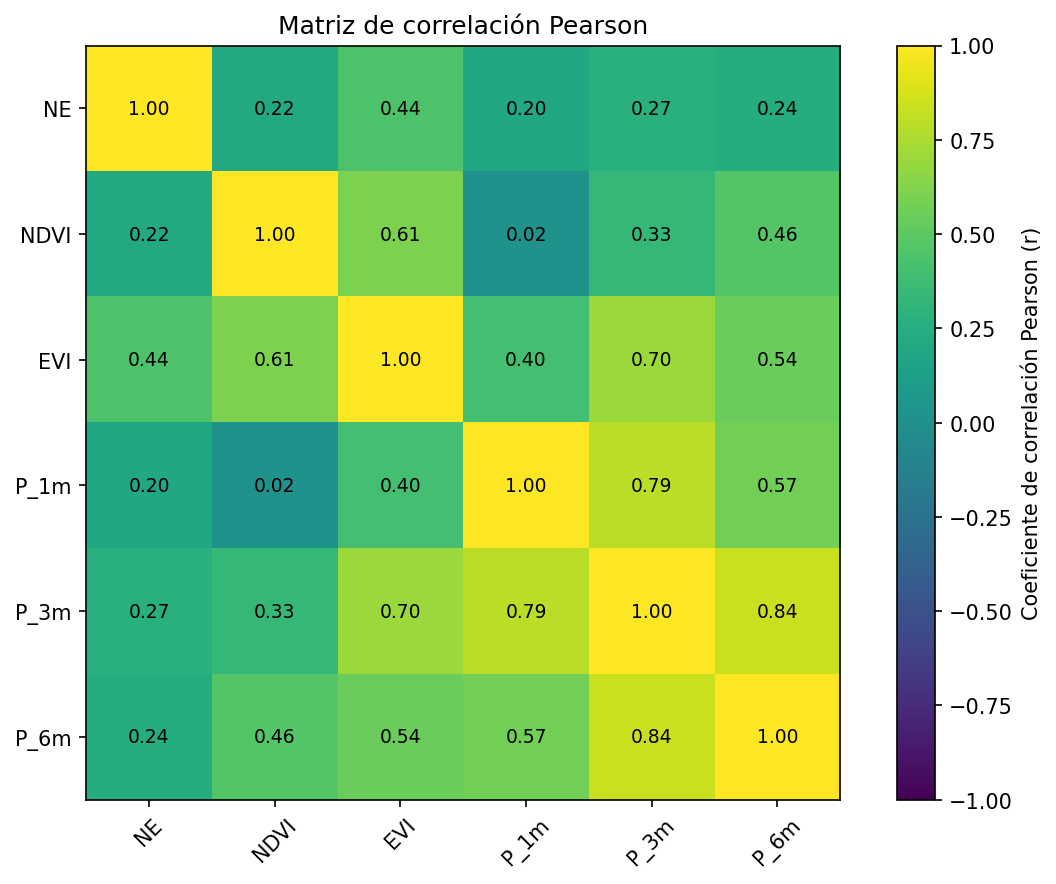

,Variable_1,Variable_2,n,Pearson_r,Pearson_R2,Pearson_p_value,Spearman_rho,Spearman_p_value,Fuerza,Significativo_0.05
0,NE,NDVI,22,0.321950,0.103651,0.143970,0.352908,0.107182,Débil,No
1,NE,EVI,22,0.483236,0.233517,0.022710,0.462451,0.030232,Moderada,Sí
2,NE,P_1m,22,0.230495,0.053128,0.302077,0.228684,0.305996,Débil,No
3,NE,P_3m,21,0.269005,0.072364,0.238341,0.262338,0.250626,Débil,No
4,NE,P_6m,21,0.238575,0.056918,0.297654,0.228571,0.318967,Débil,No
5,NDVI,EVI,22,0.632112,0.399566,0.001599,0.712027,0.000202,Fuerte,Sí
6,NDVI,P_1m,22,0.057987,0.003362,0.797702,0.278374,0.209679,Muy débil,No
7,NDVI,P_3m,21,0.331710,0.110032,0.141839,0.388312,0.081943,Débil,No
8,NDVI,P_6m,21,0.463231,0.214583,0.034444,0.523377,0.014900,Moderada,Sí
9,EVI,P_1m,22,0.416140,0.173172,0.054061,0.518916,0.013339,Moderada,No


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# ============================
# 1. DATOS DEL POZO
# ============================
data = [
("2015-01-05",95.42,0.3503,0.5123),
("2015-12-24",97.10,0.3963,0.6519),
("2016-01-18",97.40,0.4015,0.6616),
("2016-11-12",98.60,0.3698,0.6144),
("2017-02-08",98.93,0.4119,0.6593),
("2017-12-18",101.03,0.4068,0.6713),
("2018-02-01",100.79,0.3381,0.5673),
("2018-12-08",102.19,0.4540,0.7041),
("2019-01-02",103.08,0.3134,0.5100),
("2019-11-23",105.76,0.5982,0.7261),
("2020-01-02",105.38,0.3222,0.5683),
("2020-12-27",107.11,0.5010,0.7061),
("2021-01-06",107.32,0.3941,0.6750),
("2021-12-02",109.36,0.5735,0.7636),
("2022-01-01",108.60,0.3771,0.6849),
("2022-12-02",110.78,0.4851,0.7594),
("2023-02-05",111.03,0.4019,0.6246),
("2023-11-27",112.20,0.5502,0.8237),
("2024-01-01",112.50,0.3667,0.6318),
("2024-12-16",112.44,0.4297,0.6715),
("2025-07-24",114.39,0.5223,0.4747),
("2025-12-21",115.37,0.5020,0.7535)
]

df = pd.DataFrame(data, columns=["Fecha","NE","EVI","NDVI"])
df["Fecha"] = pd.to_datetime(df["Fecha"])

# ============================
# 2. CHIRPS (archivo que subiste)
# ============================
chirps = pd.read_csv('/content/CHIRPS_Mensual_Pozo_SabanasCali.csv')

chirps["date"] = pd.to_datetime(chirps["date"])
chirps = chirps.sort_values("date")

# ============================
# 3. ACUMULADOS (CLAVE)
# ============================
chirps["P_1m"] = chirps["P_mm"]
chirps["P_3m"] = chirps["P_mm"].rolling(3).sum()
chirps["P_6m"] = chirps["P_mm"].rolling(6).sum()

# ============================
# 4. EMPAREJAMIENTO TEMPORAL
# ============================
df_merge = pd.merge_asof(
    df.sort_values("Fecha"),
    chirps.sort_values("date"),
    left_on="Fecha",
    right_on="date",
    direction="backward",
    tolerance=pd.Timedelta("45D")
)

# ============================
# 5. MATRIZ DE CORRELACIÓN
# ============================
corr = df_merge[["NE","NDVI","EVI","P_1m","P_3m","P_6m"]].corr()

print(corr)


# ============================
# VARIABLES A ANALIZAR
# ============================
vars_corr = ["NE", "NDVI", "EVI", "P_1m", "P_3m", "P_6m"]

df_corr = df_merge[vars_corr].dropna()

# ============================
# MATRIZ PEARSON
# ============================
corr_pearson = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6), dpi=150)
plt.imshow(corr_pearson, vmin=-1, vmax=1)
plt.colorbar(label="Coeficiente de correlación Pearson (r)")

plt.xticks(range(len(vars_corr)), vars_corr, rotation=45)
plt.yticks(range(len(vars_corr)), vars_corr)

for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        plt.text(
            j, i,
            f"{corr_pearson.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Matriz de correlación Pearson")
plt.tight_layout()
plt.show()

# ============================
# FUNCIÓN DE CLASIFICACIÓN
# ============================
def clasificar_correlacion(r):
    abs_r = abs(r)
    if abs_r < 0.20:
        return "Muy débil"
    elif abs_r < 0.40:
        return "Débil"
    elif abs_r < 0.60:
        return "Moderada"
    elif abs_r < 0.80:
        return "Fuerte"
    else:
        return "Muy fuerte"

# ============================
# TABLA DE VALIDACIÓN
# ============================
resultados = []

for i in range(len(vars_corr)):
    for j in range(i + 1, len(vars_corr)):
        var1 = vars_corr[i]
        var2 = vars_corr[j]

        temp = df_merge[[var1, var2]].dropna()
        n = len(temp)

        if n >= 3:
            r_p, p_p = pearsonr(temp[var1], temp[var2])
            r_s, p_s = spearmanr(temp[var1], temp[var2])

            resultados.append({
                "Variable_1": var1,
                "Variable_2": var2,
                "n": n,
                "Pearson_r": r_p,
                "Pearson_R2": r_p**2,
                "Pearson_p_value": p_p,
                "Spearman_rho": r_s,
                "Spearman_p_value": p_s,
                "Fuerza": clasificar_correlacion(r_p),
                "Significativo_0.05": "Sí" if p_p < 0.05 else "No"
            })

tabla_validacion = pd.DataFrame(resultados)

tabla_validacion